In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
DF_NAME = "StreamingHistoryExtras.csv"
YEARS = [2021, 2022]
all_df = pd.DataFrame()
all_rows = 0
for year in YEARS:
    data_dir = os.path.join(str(year), "MyData", DF_NAME)
    df = pd.read_csv(data_dir)
    cur_row = len(df)
    all_rows += cur_row
    print(f"There are {cur_row} rows in {year}")
    all_df = pd.concat([all_df, df])
print(f"There are {len(all_df)} rows in total")
assert len(all_df) == all_rows, "The number of rows is not correct"

There are 17229 rows in 2021
There are 20529 rows in 2022
There are 37758 rows in total


In [3]:
all_df["endTime"] = pd.to_datetime(all_df["endTime"])

In [4]:
all_df["Year"] = all_df["endTime"].dt.year

In [5]:
all_df.head()

,endTime,artistName,trackName,Day,Week,Month,Minutes Played,Year
0,2021-01-06 13:11:00,Taylor Swift,exile (feat. Bon Iver),6,1,1,0.71,2021
1,2021-01-06 13:22:00,Taylor Swift,tolerate it,6,1,1,4.09,2021
2,2021-01-06 13:26:00,Taylor Swift,tolerate it,6,1,1,4.09,2021
3,2021-01-06 13:28:00,Taylor Swift,cardigan,6,1,1,0.78,2021
4,2021-01-06 13:42:00,Taylor Swift,the 1,6,1,1,0.59,2021


In [6]:
SAVE_DIR = os.path.join("All", "all.csv")
all_df.to_csv(SAVE_DIR, index=False)

In [7]:
start_date = all_df["endTime"].min()
end_date = all_df["endTime"].max()
print(f"Start date: {start_date}")
print(f"End date: {end_date}")
num_days = (end_date - start_date).days
print(f"Number of days: {num_days}")

Start date: 2021-01-06 13:11:00
End date: 2022-12-24 15:21:00
Number of days: 717


In [8]:
num_unique_artists = len(all_df["artistName"].unique())
print(f"There are {num_unique_artists} unique artists")
num_unique_songs = len(all_df["trackName"].unique())
print(f"There are {num_unique_songs} unique songs")

There are 167 unique artists
There are 962 unique songs


In [9]:
time_played = all_df["Minutes Played"].sum()
print(f"I have listened to {time_played} minutes of music")
hours_played = time_played / 60
print(f"I have listened to {hours_played:.2f} hours of music")
avg_time_played = time_played / num_days
print(f"I have listened to {avg_time_played:.2f} minutes of music on average. Which is {avg_time_played / 60:.2f} hours")
percentage = time_played / (num_days * 24 * 60) * 100
print(f"I have listened to {percentage:.2f}% of the time")

I have listened to 135336.5 minutes of music
I have listened to 2255.61 hours of music
I have listened to 188.75 minutes of music on average. Which is 3.15 hours
I have listened to 13.11% of the time


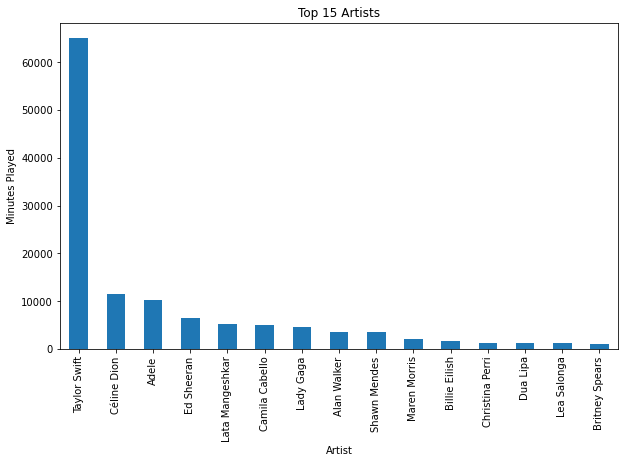

In [52]:
artist_wise = all_df.groupby("artistName").sum()
artist_wise.sort_values("Minutes Played", ascending=False, inplace=True)
data = artist_wise["Minutes Played"].head(15)
data.plot(kind="bar")
plt.title("Top 15 Artists")
plt.xlabel("Artist")
plt.ylabel("Minutes Played")
plt.show()

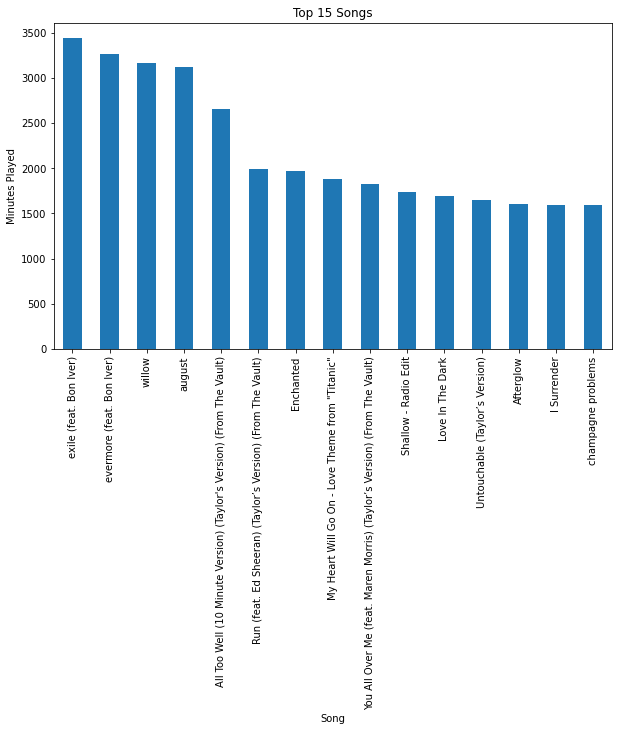

In [53]:
song_wise_time = all_df.groupby("trackName").sum()
song_wise_time.sort_values("Minutes Played", ascending=False, inplace=True)
data = song_wise_time["Minutes Played"].head(15)
data.plot(kind="bar")
plt.title("Top 15 Songs")
plt.xlabel("Song")
plt.ylabel("Minutes Played")
plt.show()

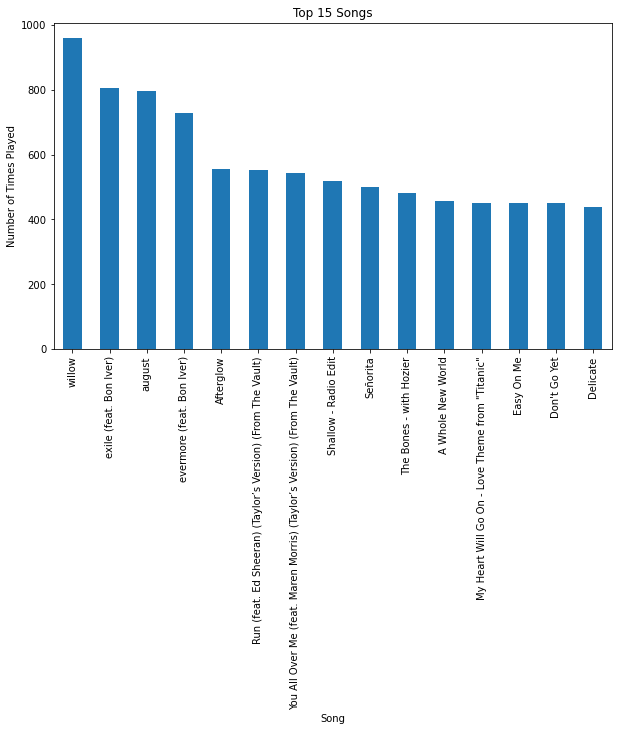

In [54]:
song_wise_num_times = all_df.groupby("trackName").count()
song_wise_num_times.sort_values("endTime", ascending=False, inplace=True)
data = song_wise_num_times["endTime"].head(15)

data.plot(kind="bar")
plt.title("Top 15 Songs")
plt.xlabel("Song")
plt.ylabel("Number of Times Played")
plt.show()

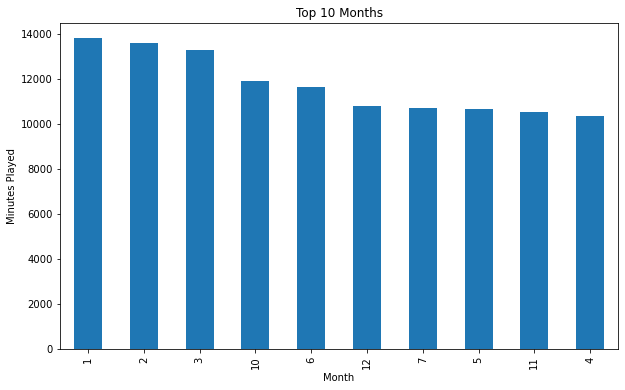

In [55]:
month_wise = all_df.groupby(all_df["Month"]).sum()
month_wise.sort_values("Minutes Played", ascending=False, inplace=True)
data = month_wise["Minutes Played"].head(10)

data.plot(kind="bar")
plt.title("Top 10 Months")
plt.xlabel("Month")
plt.ylabel("Minutes Played")
plt.show()